Web Scrapping Wikipedia Pages

In [1]:
import pandas as pd
import requests

# Dictionary of Wikipedia URLs for the ZimPSL seasons.
# We skip 2020 as the season was cancelled.
SEASONS = {
    "2017": "https://en.wikipedia.org/wiki/2017_Zimbabwe_Premier_Soccer_League",
    "2018": "https://en.wikipedia.org/wiki/2018_Zimbabwe_Premier_Soccer_League",
    "2019": "https://en.wikipedia.org/wiki/2019_Zimbabwe_Premier_Soccer_League",
    "2021-22": "https://en.wikipedia.org/wiki/2021%E2%80%9322_Zimbabwe_Premier_Soccer_League",
    "2023": "https://en.wikipedia.org/wiki/2023_Zimbabwe_Premier_Soccer_League",
    "2024": "https://en.wikipedia.org/wiki/2024_Zimbabwe_Premier_Soccer_League"
}

def scrape_wikipedia_tables():
    print("--- INITIATING WIKIPEDIA DATA MINER ---")
    all_data = []

    # Standard headers to be polite to the server
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/120.0.0.0 Safari/537.36"
    }

    for season, url in SEASONS.items():
        print(f"Scraping data for the {season} season...")
        try:
            response = requests.get(url, headers=headers)
            if response.status_code != 200:
                print(f"  -> Failed to load page for {season}")
                continue

            # pandas can automatically find and parse all HTML <table> tags on a webpage
            tables = pd.read_html(response.text)

            # Wikipedia pages have multiple tables (stadiums, scorers, etc.)
            # We look for the one that contains 'Team' and 'Pts' (Points)
            df = None
            for table in tables:
                table.columns = [str(c) for c in table.columns]
                if any('Team' in col for col in table.columns) and any('Pts' in col for col in table.columns):
                    df = table
                    break

            if df is not None:
                # Identify exact column names by checking substrings (Wiki formatting changes year to year)
                team_col = [c for c in df.columns if 'Team' in c][0]
                played_col = [c for c in df.columns if 'Pld' in c or 'Played' in c][0]
                win_col = [c for c in df.columns if 'W' == c.strip() or 'Wins' in c][0]
                draw_col = [c for c in df.columns if 'D' == c.strip() or 'Draws' in c][0]
                loss_col = [c for c in df.columns if 'L' == c.strip() or 'Losses' in c][0]
                gf_col = [c for c in df.columns if 'GF' == c.strip() or 'Goals For' in c][0]
                ga_col = [c for c in df.columns if 'GA' == c.strip() or 'Goals Against' in c][0]
                pts_col = [c for c in df.columns if 'Pts' in c or 'Points' in c][0]

                # Keep only the essential columns and rename them cleanly
                clean_df = df[[team_col, played_col, win_col, draw_col, loss_col, gf_col, ga_col, pts_col]].copy()
                clean_df.columns = ['Team', 'Played', 'Wins', 'Draws', 'Losses', 'Goals_For', 'Goals_Against', 'Points']

                # Tag these rows with the current season
                clean_df['Season'] = season

                # Clean team names (remove Wikipedia reference tags like "[a]" or "(C)")
                clean_df['Team'] = clean_df['Team'].str.replace(r'\[.*\]', '', regex=True)
                clean_df['Team'] = clean_df['Team'].str.replace(r'\(.*\)', '', regex=True)
                clean_df['Team'] = clean_df['Team'].str.strip()

                # Drop rows where 'Team' is empty or it's a summary row
                clean_df = clean_df.dropna(subset=['Team'])
                clean_df = clean_df[~clean_df['Team'].str.contains('Total|Update', case=False, na=False)]

                numeric_cols = ['Played', 'Wins', 'Draws', 'Losses', 'Goals_For', 'Goals_Against', 'Points']
                for col in numeric_cols:
                    clean_df[col] = pd.to_numeric(clean_df[col], errors='coerce')

                # Drop rows that failed numeric conversion (removes embedded table headers)
                clean_df = clean_df.dropna(subset=['Points'])

                all_data.append(clean_df)
                print(f"  -> Successfully extracted {len(clean_df)} teams.")
            else:
                print(f"  -> League table not found on page for {season}.")

        except Exception as e:
            print(f"  -> Error processing {season}: {e}")

    if all_data:
        # Combine all individual season tables into one massive DataFrame
        master_df = pd.concat(all_data, ignore_index=True)

        # --- FEATURE ENGINEERING ---
        # Generating new advanced metrics from the raw data
        master_df['Goal_Difference'] = master_df['Goals_For'] - master_df['Goals_Against']
        master_df['Win_Percentage'] = round((master_df['Wins'] / master_df['Played']) * 100, 2)
        master_df['Goals_Per_Game'] = round(master_df['Goals_For'] / master_df['Played'], 2)
        master_df['Points_Per_Game'] = round(master_df['Points'] / master_df['Played'], 2)

        # Save to CSV
        filename = "zimpsl_historical_warehouse.csv"
        master_df.to_csv(filename, index=False)
        print(f"\nSUCCESS! Exported {len(master_df)} rows of deep historical data to '{filename}'")

        return master_df
    else:
        print("\nFailed to extract any data.")
        return None

if __name__ == "__main__":
    df = scrape_wikipedia_tables()
    if df is not None:
        print("\nData Preview (First 5 Rows):")
        print(df.head())

--- INITIATING WIKIPEDIA DATA MINER ---
Scraping data for the 2017 season...


/tmp/ipykernel_1253/2772368237.py:33: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


  -> Successfully extracted 18 teams.
Scraping data for the 2018 season...
  -> Successfully extracted 17 teams.
Scraping data for the 2019 season...


/tmp/ipykernel_1253/2772368237.py:33: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
/tmp/ipykernel_1253/2772368237.py:33: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


  -> Successfully extracted 18 teams.
Scraping data for the 2021-22 season...
  -> Successfully extracted 18 teams.
Scraping data for the 2023 season...


/tmp/ipykernel_1253/2772368237.py:33: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
/tmp/ipykernel_1253/2772368237.py:33: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


  -> Successfully extracted 18 teams.
Scraping data for the 2024 season...
  -> Successfully extracted 18 teams.

SUCCESS! Exported 107 rows of deep historical data to 'zimpsl_historical_warehouse.csv'

Data Preview (First 5 Rows):
             Team  Played  Wins  Draws  Losses  Goals_For  Goals_Against  \
0        Platinum      34    20     12       2         40             15   
1         Dynamos      34    21      7       6         55             26   
2  Ngezi Platinum      34    19      8       7         54             30   
3     Chicken Inn      34    18      7       9         34             22   
4     CAPS United      34    15     13       6         43             29   

   Points Season  Goal_Difference  Win_Percentage  Goals_Per_Game  \
0    72.0   2017               25           58.82            1.18   
1    70.0   2017               29           61.76            1.62   
2    65.0   2017               24           55.88            1.59   
3    61.0   2017               12  

/tmp/ipykernel_1253/2772368237.py:33: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [ ]:
Data Cleaning

In [2]:
import pandas as pd
import requests
import os

# Try to import Google Colab drive library
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Dictionary of Wikipedia URLs for the ZimPSL seasons.
# We skip 2020 as the season was cancelled.
SEASONS = {
    "2017": "https://en.wikipedia.org/wiki/2017_Zimbabwe_Premier_Soccer_League",
    "2018": "https://en.wikipedia.org/wiki/2018_Zimbabwe_Premier_Soccer_League",
    "2019": "https://en.wikipedia.org/wiki/2019_Zimbabwe_Premier_Soccer_League",
    "2021-22": "https://en.wikipedia.org/wiki/2021%E2%80%9322_Zimbabwe_Premier_Soccer_League",
    "2023": "https://en.wikipedia.org/wiki/2023_Zimbabwe_Premier_Soccer_League",
    "2024": "https://en.wikipedia.org/wiki/2024_Zimbabwe_Premier_Soccer_League"
}

def scrape_wikipedia_tables():
    print("--- INITIATING WIKIPEDIA DATA MINER ---")
    all_data = []

    # Standard headers to be polite to the server
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/120.0.0.0 Safari/537.36"
    }

    for season, url in SEASONS.items():
        print(f"Scraping data for the {season} season...")
        try:
            response = requests.get(url, headers=headers)
            if response.status_code != 200:
                print(f"  -> Failed to load page for {season}")
                continue

            # pandas can automatically find and parse all HTML <table> tags on a webpage
            tables = pd.read_html(response.text)

            # Wikipedia pages have multiple tables (stadiums, scorers, etc.)
            # We look for the one that contains 'Team' and 'Pts' (Points)
            df = None
            for table in tables:
                table.columns = [str(c) for c in table.columns]
                if any('Team' in col for col in table.columns) and any('Pts' in col for col in table.columns):
                    df = table
                    break

            if df is not None:
                # Identify exact column names by checking substrings (Wiki formatting changes year to year)
                team_col = [c for c in df.columns if 'Team' in c][0]
                played_col = [c for c in df.columns if 'Pld' in c or 'Played' in c][0]
                win_col = [c for c in df.columns if 'W' == c.strip() or 'Wins' in c][0]
                draw_col = [c for c in df.columns if 'D' == c.strip() or 'Draws' in c][0]
                loss_col = [c for c in df.columns if 'L' == c.strip() or 'Losses' in c][0]
                gf_col = [c for c in df.columns if 'GF' == c.strip() or 'Goals For' in c][0]
                ga_col = [c for c in df.columns if 'GA' == c.strip() or 'Goals Against' in c][0]
                pts_col = [c for c in df.columns if 'Pts' in c or 'Points' in c][0]

                # Keep only the essential columns and rename them cleanly
                clean_df = df[[team_col, played_col, win_col, draw_col, loss_col, gf_col, ga_col, pts_col]].copy()
                clean_df.columns = ['Team', 'Played', 'Wins', 'Draws', 'Losses', 'Goals_For', 'Goals_Against', 'Points']

                # Tag these rows with the current season
                clean_df['Season'] = season

                # Clean team names (remove Wikipedia reference tags like "[a]" or "(C)")
                clean_df['Team'] = clean_df['Team'].str.replace(r'\[.*\]', '', regex=True)
                clean_df['Team'] = clean_df['Team'].str.replace(r'\(.*\)', '', regex=True)
                clean_df['Team'] = clean_df['Team'].str.strip()

                # Drop rows where 'Team' is empty or it's a summary row
                clean_df = clean_df.dropna(subset=['Team'])
                clean_df = clean_df[~clean_df['Team'].str.contains('Total|Update', case=False, na=False)]

                numeric_cols = ['Played', 'Wins', 'Draws', 'Losses', 'Goals_For', 'Goals_Against', 'Points']
                for col in numeric_cols:
                    clean_df[col] = pd.to_numeric(clean_df[col], errors='coerce')

                # Drop rows that failed numeric conversion (removes embedded table headers)
                clean_df = clean_df.dropna(subset=['Points'])

                all_data.append(clean_df)
                print(f"  -> Successfully extracted {len(clean_df)} teams.")
            else:
                print(f"  -> League table not found on page for {season}.")

        except Exception as e:
            print(f"  -> Error processing {season}: {e}")

    if all_data:
        # Combine all individual season tables into one massive DataFrame
        master_df = pd.concat(all_data, ignore_index=True)

        # --- FEATURE ENGINEERING ---
        # Generating new advanced metrics from the raw data
        master_df['Goal_Difference'] = master_df['Goals_For'] - master_df['Goals_Against']
        master_df['Win_Percentage'] = round((master_df['Wins'] / master_df['Played']) * 100, 2)
        master_df['Goals_Per_Game'] = round(master_df['Goals_For'] / master_df['Played'], 2)

        # Adding a new metric for defensive strength for our next analysis
        master_df['Conceded_Per_Game'] = round(master_df['Goals_Against'] / master_df['Played'], 2)
        master_df['Points_Per_Game'] = round(master_df['Points'] / master_df['Played'], 2)

        # --- SAVE TO GOOGLE DRIVE (If in Colab) ---
        if IN_COLAB:
            print("\nConnecting to Google Drive...")
            drive.mount('/content/drive')
            save_dir = '/content/drive/MyDrive/ZimPSL_Analytics'
            os.makedirs(save_dir, exist_ok=True)
            filename = os.path.join(save_dir, "zimpsl_historical_warehouse.csv")
        else:
            filename = "zimpsl_historical_warehouse.csv"

        master_df.to_csv(filename, index=False)
        print(f"\nSUCCESS! Exported {len(master_df)} rows of deep historical data to '{filename}'")

        return master_df
    else:
        print("\nFailed to extract any data.")
        return None

if __name__ == "__main__":
    df = scrape_wikipedia_tables()
    if df is not None:
        print("\nData Preview (First 5 Rows):")
        print(df.head())

--- INITIATING WIKIPEDIA DATA MINER ---
Scraping data for the 2017 season...
  -> Successfully extracted 18 teams.
Scraping data for the 2018 season...


/tmp/ipykernel_1253/3004286080.py:41: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
/tmp/ipykernel_1253/3004286080.py:41: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


  -> Successfully extracted 17 teams.
Scraping data for the 2019 season...
  -> Successfully extracted 18 teams.
Scraping data for the 2021-22 season...


/tmp/ipykernel_1253/3004286080.py:41: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
/tmp/ipykernel_1253/3004286080.py:41: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


  -> Successfully extracted 18 teams.
Scraping data for the 2023 season...
  -> Successfully extracted 18 teams.
Scraping data for the 2024 season...


/tmp/ipykernel_1253/3004286080.py:41: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
/tmp/ipykernel_1253/3004286080.py:41: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


  -> Successfully extracted 18 teams.

Connecting to Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

SUCCESS! Exported 107 rows of deep historical data to '/content/drive/MyDrive/ZimPSL_Analytics/zimpsl_historical_warehouse.csv'

Data Preview (First 5 Rows):
             Team  Played  Wins  Draws  Losses  Goals_For  Goals_Against  \
0        Platinum      34    20     12       2         40             15   
1         Dynamos      34    21      7       6         55             26   
2  Ngezi Platinum      34    19      8       7         54             30   
3     Chicken Inn      34    18      7       9         34             22   
4     CAPS United      34    15     13       6         43             29   

   Points Season  Goal_Difference  Win_Percentage  Goals_Per_Game  \
0    72.0   2017               25           58.82            1.18   
1    70.0   2017               29           61.7

In [4]:
!pip install adjustText

Data Visualisation and Analysis

In [10]:
import pandas as pd
import requests
import os

# Try to import Google Colab drive library
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Dictionary of Wikipedia URLs for the ZimPSL seasons.
# We skip 2020 as the season was cancelled.
SEASONS = {
    "2017": "https://en.wikipedia.org/wiki/2017_Zimbabwe_Premier_Soccer_League",
    "2018": "https://en.wikipedia.org/wiki/2018_Zimbabwe_Premier_Soccer_League",
    "2019": "https://en.wikipedia.org/wiki/2019_Zimbabwe_Premier_Soccer_League",
    "2021-22": "https://en.wikipedia.org/wiki/2021%E2%80%9322_Zimbabwe_Premier_Soccer_League",
    "2023": "https://en.wikipedia.org/wiki/2023_Zimbabwe_Premier_Soccer_League",
    "2024": "https://en.wikipedia.org/wiki/2024_Zimbabwe_Premier_Soccer_League"
}

def scrape_wikipedia_tables():
    print("--- INITIATING WIKIPEDIA DATA MINER ---")
    all_data = []

    # Standard headers to be polite to the server
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/120.0.0.0 Safari/537.36"
    }

    for season, url in SEASONS.items():
        print(f"Scraping data for the {season} season...")
        try:
            response = requests.get(url, headers=headers)
            if response.status_code != 200:
                print(f"  -> Failed to load page for {season}")
                continue

            # pandas can automatically find and parse all HTML <table> tags on a webpage
            tables = pd.read_html(response.text)

            # Wikipedia pages have multiple tables (stadiums, scorers, etc.)
            # We look for the one that contains 'Team' and 'Pts' (Points)
            df = None
            for table in tables:
                table.columns = [str(c) for c in table.columns]
                if any('Team' in col for col in table.columns) and any('Pts' in col for col in table.columns):
                    df = table
                    break

            if df is not None:
                # Identify exact column names by checking substrings (Wiki formatting changes year to year)
                team_col = [c for c in df.columns if 'Team' in c][0]
                played_col = [c for c in df.columns if 'Pld' in c or 'Played' in c][0]
                win_col = [c for c in df.columns if 'W' == c.strip() or 'Wins' in c][0]
                draw_col = [c for c in df.columns if 'D' == c.strip() or 'Draws' in c][0]
                loss_col = [c for c in df.columns if 'L' == c.strip() or 'Losses' in c][0]
                gf_col = [c for c in df.columns if 'GF' == c.strip() or 'Goals For' in c][0]
                ga_col = [c for c in df.columns if 'GA' == c.strip() or 'Goals Against' in c][0]
                pts_col = [c for c in df.columns if 'Pts' in c or 'Points' in c][0]

                # Keep only the essential columns and rename them cleanly
                clean_df = df[[team_col, played_col, win_col, draw_col, loss_col, gf_col, ga_col, pts_col]].copy()
                clean_df.columns = ['Team', 'Played', 'Wins', 'Draws', 'Losses', 'Goals_For', 'Goals_Against', 'Points']

                # Tag these rows with the current season
                clean_df['Season'] = season

                # Clean team names (remove Wikipedia reference tags like "[a]" or "(C)")
                clean_df['Team'] = clean_df['Team'].str.replace(r'\[.*\]', '', regex=True)
                clean_df['Team'] = clean_df['Team'].str.replace(r'\(.*\)', '', regex=True)
                clean_df['Team'] = clean_df['Team'].str.strip()

                # Drop rows where 'Team' is empty or it's a summary row
                clean_df = clean_df.dropna(subset=['Team'])
                clean_df = clean_df[~clean_df['Team'].str.contains('Total|Update', case=False, na=False)]

                numeric_cols = ['Played', 'Wins', 'Draws', 'Losses', 'Goals_For', 'Goals_Against', 'Points']
                for col in numeric_cols:
                    clean_df[col] = pd.to_numeric(clean_df[col], errors='coerce')

                # Drop rows that failed numeric conversion (removes embedded table headers)
                clean_df = clean_df.dropna(subset=['Points'])

                all_data.append(clean_df)
                print(f"  -> Successfully extracted {len(clean_df)} teams.")
            else:
                print(f"  -> League table not found on page for {season}.")

        except Exception as e:
            print(f"  -> Error processing {season}: {e}")

    if all_data:
        # Combine all individual season tables into one massive DataFrame
        master_df = pd.concat(all_data, ignore_index=True)

        # --- FEATURE ENGINEERING ---
        # Generating new advanced metrics from the raw data
        master_df['Goal_Difference'] = master_df['Goals_For'] - master_df['Goals_Against']
        master_df['Win_Percentage'] = round((master_df['Wins'] / master_df['Played']) * 100, 2)
        master_df['Goals_Per_Game'] = round(master_df['Goals_For'] / master_df['Played'], 2)

        # Adding a new metric for defensive strength for our next analysis
        master_df['Conceded_Per_Game'] = round(master_df['Goals_Against'] / master_df['Played'], 2)
        master_df['Points_Per_Game'] = round(master_df['Points'] / master_df['Played'], 2)

        # --- NEW CODE: STANDARDIZE TEAM NAMES ---
        # Fixing the Wikipedia naming inconsistencies
        name_mapping = {
            "Platinum": "FC Platinum",
            "Ngezi Platinum Stars": "Ngezi Platinum",
            "Yadah Stars": "Yadah",
            "Kariba": "ZPC Kariba"
        }
        master_df['Team'] = master_df['Team'].replace(name_mapping)
        # ----------------------------------------

        # --- SAVE TO GOOGLE DRIVE (If in Colab) ---
        if IN_COLAB:
            print("\nConnecting to Google Drive...")
            drive.mount('/content/drive')
            save_dir = '/content/drive/MyDrive/ZimPSL_Analytics'
            os.makedirs(save_dir, exist_ok=True)
            filename = os.path.join(save_dir, "zimpsl_historical_warehouse.csv")
        else:
            filename = "zimpsl_historical_warehouse.csv"

        master_df.to_csv(filename, index=False)
        print(f"\nSUCCESS! Exported {len(master_df)} rows of deep historical data to '{filename}'")

        return master_df
    else:
        print("\nFailed to extract any data.")
        return None

if __name__ == "__main__":
    df = scrape_wikipedia_tables()
    if df is not None:
        print("\nData Preview (First 5 Rows):")
        print(df.head())

--- INITIATING WIKIPEDIA DATA MINER ---
Scraping data for the 2017 season...
  -> Successfully extracted 18 teams.
Scraping data for the 2018 season...


/tmp/ipykernel_1253/4110720821.py:41: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
/tmp/ipykernel_1253/4110720821.py:41: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


  -> Successfully extracted 17 teams.
Scraping data for the 2019 season...
  -> Successfully extracted 18 teams.
Scraping data for the 2021-22 season...


/tmp/ipykernel_1253/4110720821.py:41: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
/tmp/ipykernel_1253/4110720821.py:41: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


  -> Successfully extracted 18 teams.
Scraping data for the 2023 season...
  -> Successfully extracted 18 teams.
Scraping data for the 2024 season...


/tmp/ipykernel_1253/4110720821.py:41: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
/tmp/ipykernel_1253/4110720821.py:41: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


  -> Successfully extracted 18 teams.

Connecting to Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

SUCCESS! Exported 107 rows of deep historical data to '/content/drive/MyDrive/ZimPSL_Analytics/zimpsl_historical_warehouse.csv'

Data Preview (First 5 Rows):
             Team  Played  Wins  Draws  Losses  Goals_For  Goals_Against  \
0     FC Platinum      34    20     12       2         40             15   
1         Dynamos      34    21      7       6         55             26   
2  Ngezi Platinum      34    19      8       7         54             30   
3     Chicken Inn      34    18      7       9         34             22   
4     CAPS United      34    15     13       6         43             29   

   Points Season  Goal_Difference  Win_Percentage  Goals_Per_Game  \
0    72.0   2017               25           58.82            1.18   
1    70.0   2017               29           61.7

/tmp/ipykernel_1253/3989435882.py:102: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  plt.savefig(output_png, dpi=300, bbox_inches='tight')
/tmp/ipykernel_1253/3989435882.py:102: UserWarning: Glyph 127871 (\N{POPCORN}) missing from font(s) DejaVu Sans.
  plt.savefig(output_png, dpi=300, bbox_inches='tight')
/tmp/ipykernel_1253/3989435882.py:102: UserWarning: Glyph 128652 (\N{BUS}) missing from font(s) DejaVu Sans.
  plt.savefig(output_png, dpi=300, bbox_inches='tight')
/tmp/ipykernel_1253/3989435882.py:102: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(output_png, dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127871 (\N{POPCORN}) missing from 

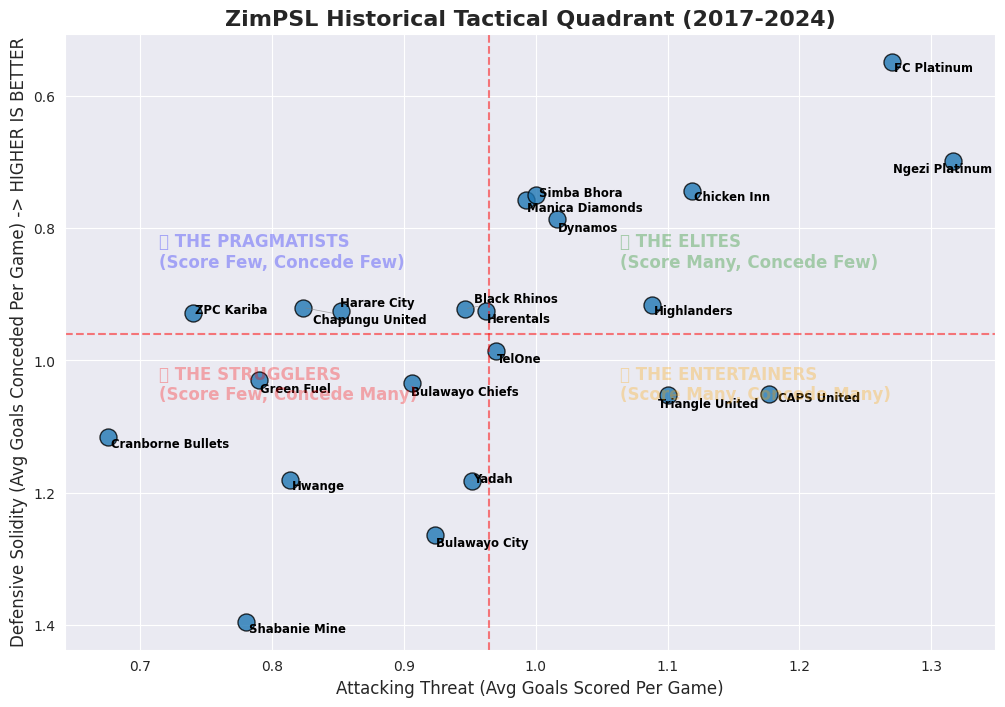

/tmp/ipykernel_1253/3989435882.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Win_Rate', y='Team', data=veterans, palette='viridis')



Masterpiece generated! Saved as /content/drive/MyDrive/ZimPSL_Analytics/ZimPSL_Tactical_Quadrant.png

Generating Historical Dominance Chart...


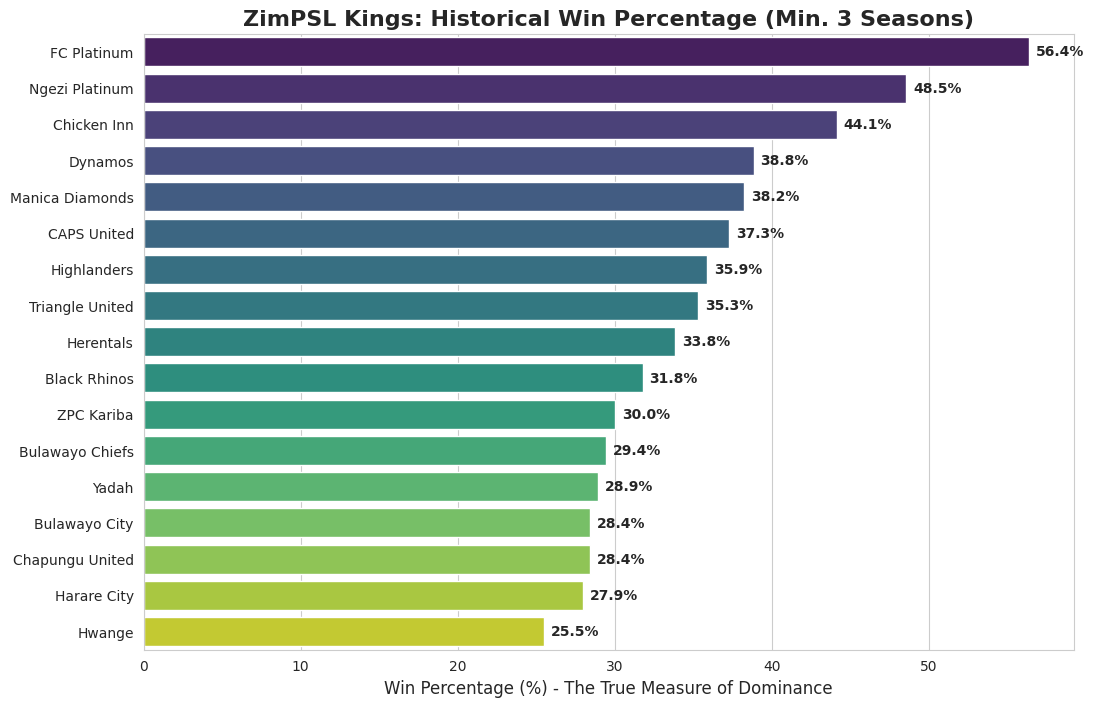

Dominance chart saved as /content/drive/MyDrive/ZimPSL_Analytics/ZimPSL_Historical_WinRates.png

Generating Points Timeline Chart...


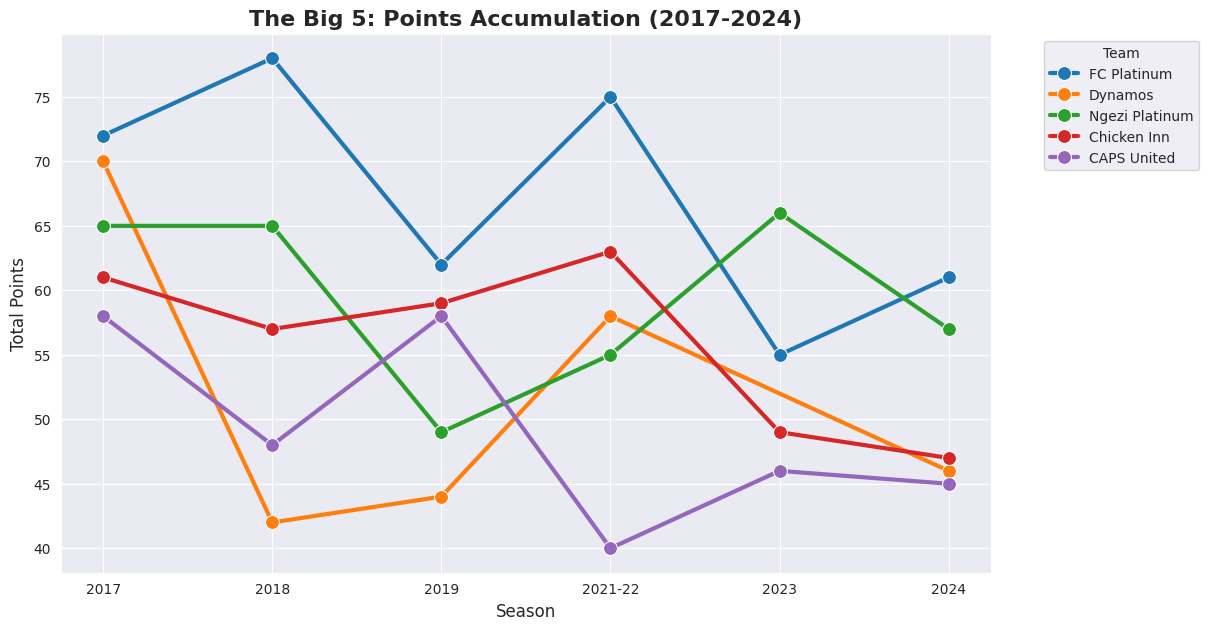

Timeline chart saved as /content/drive/MyDrive/ZimPSL_Analytics/ZimPSL_Points_Timeline.png

Generating Entertainers Index...

 🍿 THE ZIMPSL ULTIMATE ENTERTAINERS (2018-2024) 🍿
           Team  Matches  GF  GA  Entertainment_Index
    CAPS United      170 197 185                 2.25
Triangle United      136 150 143                 2.15
          Yadah      170 163 201                 2.14
  Bulawayo City       68  57  85                 2.09
         Hwange       68  54  82                 2.00
    Highlanders      136 150 121                 1.99
         TelOne       68  66  67                 1.96
Bulawayo Chiefs      170 154 176                 1.94
 Ngezi Platinum      170 215 112                 1.92
    Chicken Inn      170 194 130                 1.91



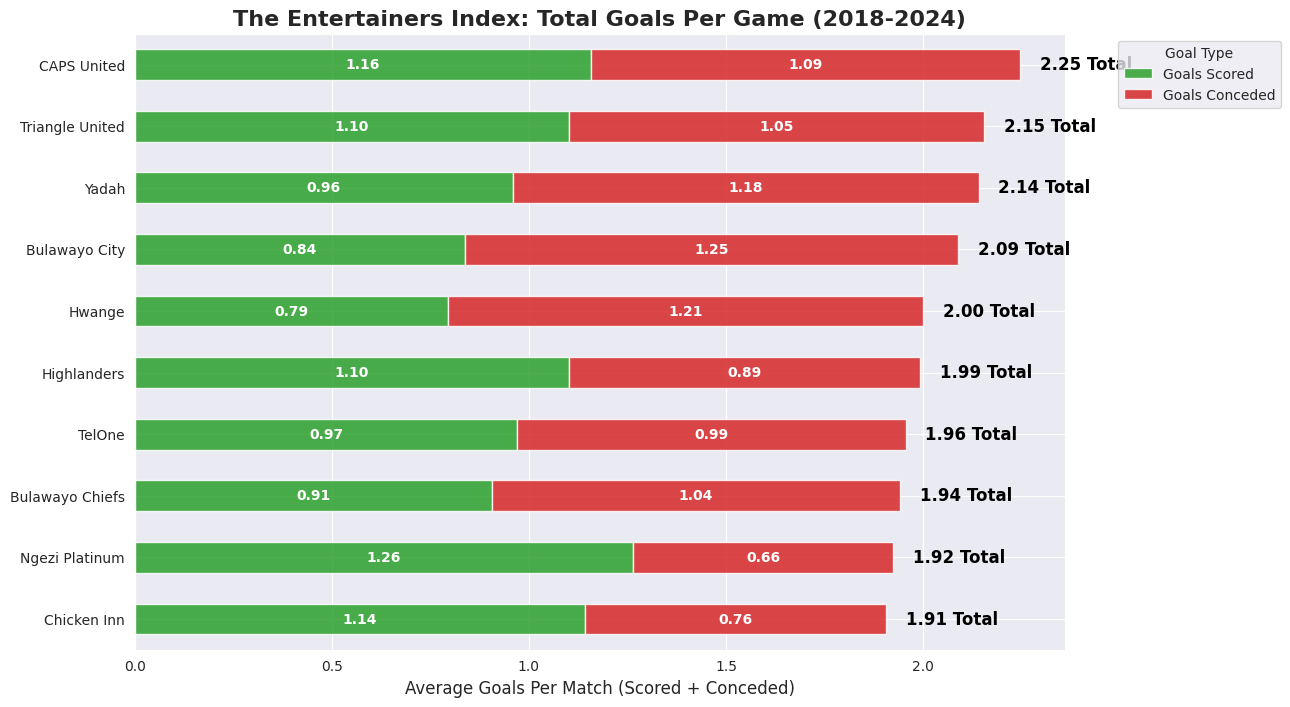

Entertainers Index chart saved as /content/drive/MyDrive/ZimPSL_Analytics/ZimPSL_Entertainers_Index.png


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

try:
    from adjustText import adjust_text
    HAS_ADJUST_TEXT = True
except ImportError:
    HAS_ADJUST_TEXT = False

# Helper to check if in Colab to get the right file path
try:
    from google.colab import drive
    IN_COLAB = True
    file_path = '/content/drive/MyDrive/ZimPSL_Analytics/zimpsl_historical_warehouse.csv'
except ImportError:
    IN_COLAB = False
    file_path = 'zimpsl_historical_warehouse.csv'

def plot_tactical_quadrant():
    # 1. Load the data
    if not os.path.exists(file_path):
        print(f"Error: Could not find {file_path}. Did you run the scraper first?")
        return

    df = pd.read_csv(file_path)

    # 2. Aggregate Data: Calculate historical average for each team over the 7 years
    # We only want teams that have played at least 2 seasons to avoid outliers
    team_stats = df.groupby('Team').agg(
        Seasons_Played=('Season', 'count'),
        Avg_Goals_Scored=('Goals_Per_Game', 'mean'),
        Avg_Goals_Conceded=('Conceded_Per_Game', 'mean')
    ).reset_index()

    # Filter for established teams (2+ seasons)
    team_stats = team_stats[team_stats['Seasons_Played'] >= 2]

    # 3. Calculate League Averages to draw our Quadrant Lines
    league_avg_scored = team_stats['Avg_Goals_Scored'].mean()
    league_avg_conceded = team_stats['Avg_Goals_Conceded'].mean()

    # 4. Set up the Visualization (The Fun Part!)
    plt.figure(figsize=(12, 8))
    sns.set_style("darkgrid")

    # Create the scatter plot
    scatter = sns.scatterplot(
        data=team_stats,
        x='Avg_Goals_Scored',
        y='Avg_Goals_Conceded',
        s=150, # Size of the dots
        color='#1f77b4',
        edgecolor='black',
        alpha=0.8
    )

    # 5. Draw the Quadrant Lines
    plt.axvline(x=league_avg_scored, color='red', linestyle='--', alpha=0.5)
    plt.axhline(y=league_avg_conceded, color='red', linestyle='--', alpha=0.5)

    # 6. Label every dot with the Team Name (Using adjustText to fix overlaps!)
    texts = []
    for i in range(team_stats.shape[0]):
        texts.append(
            plt.text(
                team_stats['Avg_Goals_Scored'].iloc[i],
                team_stats['Avg_Goals_Conceded'].iloc[i],
                team_stats['Team'].iloc[i],
                size='small',
                color='black',
                weight='semibold'
            )
        )

    if HAS_ADJUST_TEXT:
        # This magically pushes overlapping text apart and draws connecting lines
        adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5, alpha=0.7))
    else:
        print("\n[Tip] Install 'adjustText' (run: !pip install adjustText) to automatically fix overlapping team names!")

    # 7. Add Quadrant Titles
    plt.text(league_avg_scored + 0.1, league_avg_conceded - 0.1, '👑 THE ELITES\n(Score Many, Concede Few)', alpha=0.3, fontsize=12, fontweight='bold', color='green')
    plt.text(league_avg_scored + 0.1, league_avg_conceded + 0.1, '🍿 THE ENTERTAINERS\n(Score Many, Concede Many)', alpha=0.3, fontsize=12, fontweight='bold', color='orange')
    plt.text(league_avg_scored - 0.25, league_avg_conceded - 0.1, '🚌 THE PRAGMATISTS\n(Score Few, Concede Few)', alpha=0.3, fontsize=12, fontweight='bold', color='blue')
    plt.text(league_avg_scored - 0.25, league_avg_conceded + 0.1, '📉 THE STRUGGLERS\n(Score Few, Concede Many)', alpha=0.3, fontsize=12, fontweight='bold', color='red')

    # 8. Polish the Chart
    # We invert the Y-axis so conceding FEWER goals is at the TOP (better)
    plt.gca().invert_yaxis()

    plt.title('ZimPSL Historical Tactical Quadrant (2017-2024)', fontsize=16, fontweight='bold')
    plt.xlabel('Attacking Threat (Avg Goals Scored Per Game)', fontsize=12)
    plt.ylabel('Defensive Solidity (Avg Goals Conceded Per Game) -> HIGHER IS BETTER', fontsize=12)

    # Save the beautiful plot
    output_png = "ZimPSL_Tactical_Quadrant.png"
    if IN_COLAB:
        output_png = f'/content/drive/MyDrive/ZimPSL_Analytics/{output_png}'

    plt.savefig(output_png, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nMasterpiece generated! Saved as {output_png}")


def plot_historical_dominance():
    """EDA 1: Bar chart showing historical win percentages to see who is truly 'better'."""
    print("\nGenerating Historical Dominance Chart...")
    if not os.path.exists(file_path): return
    df = pd.read_csv(file_path)

    # Calculate overall stats per team across all seasons
    team_stats = df.groupby('Team').agg(
        Total_Played=('Played', 'sum'),
        Total_Wins=('Wins', 'sum'),
        Seasons=('Season', 'count')
    ).reset_index()

    # Filter for established teams (3+ seasons) to remove one-season wonders
    veterans = team_stats[team_stats['Seasons'] >= 3].copy()
    veterans['Win_Rate'] = (veterans['Total_Wins'] / veterans['Total_Played']) * 100
    veterans = veterans.sort_values('Win_Rate', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.set_style("whitegrid")

    # The Bar Plot
    ax = sns.barplot(x='Win_Rate', y='Team', data=veterans, palette='viridis')

    # Add actual percentage numbers to the bars
    for i in ax.containers:
        ax.bar_label(i, fmt='%.1f%%', padding=5, fontweight='bold', fontsize=10)

    plt.title('ZimPSL Kings: Historical Win Percentage (Min. 3 Seasons)', fontsize=16, fontweight='bold')
    plt.xlabel('Win Percentage (%) - The True Measure of Dominance', fontsize=12)
    plt.ylabel('', fontsize=12)

    output_png = "ZimPSL_Historical_WinRates.png"
    if IN_COLAB: output_png = f'/content/drive/MyDrive/ZimPSL_Analytics/{output_png}'

    plt.savefig(output_png, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Dominance chart saved as {output_png}")


def plot_points_timeline():
    """EDA 2: Line chart tracking the points of the Top 5 most successful teams over time."""
    print("\nGenerating Points Timeline Chart...")
    if not os.path.exists(file_path): return
    df = pd.read_csv(file_path)

    # Find the Top 5 teams based on all-time total points
    top_teams = df.groupby('Team')['Points'].sum().nlargest(5).index.tolist()
    elite_df = df[df['Team'].isin(top_teams)]

    plt.figure(figsize=(12, 7))
    sns.set_style("darkgrid")

    # The Line Plot
    sns.lineplot(
        data=elite_df,
        x='Season',
        y='Points',
        hue='Team',
        marker='o',
        linewidth=3,
        markersize=10,
        palette='tab10'
    )

    plt.title('The Big 5: Points Accumulation (2017-2024)', fontsize=16, fontweight='bold')
    plt.xlabel('Season', fontsize=12)
    plt.ylabel('Total Points', fontsize=12)

    # Move legend outside the plot so it doesn't cover data
    plt.legend(title='Team', bbox_to_anchor=(1.05, 1), loc='upper left')

    output_png = "ZimPSL_Points_Timeline.png"
    if IN_COLAB: output_png = f'/content/drive/MyDrive/ZimPSL_Analytics/{output_png}'

    plt.savefig(output_png, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Timeline chart saved as {output_png}")


def plot_entertainers_index():
    """EDA 3: The Entertainers Index - Teams with the highest combined goals per game (Last 5 Years)."""
    print("\nGenerating Entertainers Index...")
    if not os.path.exists(file_path):
        return
    df = pd.read_csv(file_path)

    # The last 5 active seasons (skipping 2020 as it was cancelled)
    last_5_seasons = ['2018', '2019', '2021-22', '2023', '2024']

    # Convert 'Season' column to string just in case it was parsed as integers
    df['Season'] = df['Season'].astype(str)
    df_5yrs = df[df['Season'].isin(last_5_seasons)]

    stats = df_5yrs.groupby('Team').agg(
        Matches=('Played', 'sum'),
        GF=('Goals_For', 'sum'),
        GA=('Goals_Against', 'sum')
    ).reset_index()

    # Filter out teams that didn't play at least 60 games (~2 seasons)
    # to avoid relegated teams skewing the data with tiny sample sizes
    stats = stats[stats['Matches'] >= 60].copy()

    # Calculate the per-game metrics
    stats['GF_Per_Game'] = stats['GF'] / stats['Matches']
    stats['GA_Per_Game'] = stats['GA'] / stats['Matches']

    # The ultimate Entertainment Metric: Total Goals witnessed per match
    stats['Entertainment_Index'] = stats['GF_Per_Game'] + stats['GA_Per_Game']

    # Sort and grab the Top 10 most entertaining teams
    top_entertainers = stats.sort_values('Entertainment_Index', ascending=False).head(10).reset_index(drop=True)

    print("\n" + "="*60)
    print(" 🍿 THE ZIMPSL ULTIMATE ENTERTAINERS (2018-2024) 🍿")
    print("="*60)
    # Format the dataframe for a beautiful console output
    display_df = top_entertainers.copy()
    display_df['GF_Per_Game'] = display_df['GF_Per_Game'].round(2)
    display_df['GA_Per_Game'] = display_df['GA_Per_Game'].round(2)
    display_df['Entertainment_Index'] = display_df['Entertainment_Index'].round(2)
    print(display_df[['Team', 'Matches', 'GF', 'GA', 'Entertainment_Index']].to_string(index=False))
    print("="*60 + "\n")

    # Prepare data specifically for Pandas stacked plotting
    plot_data = top_entertainers.set_index('Team')[['GF_Per_Game', 'GA_Per_Game']]
    plot_data.columns = ['Goals Scored', 'Goals Conceded']

    # Create the figure
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.set_style("darkgrid")

    # Draw a stacked horizontal bar chart (Green for scoring, Red for conceding)
    plot_data.plot(kind='barh', stacked=True, ax=ax, color=['#2ca02c', '#d62728'], alpha=0.85)

    # Add the text values inside the bars for extra detail
    for n, x in enumerate([*ax.patches]):
        if x.get_width() > 0: # Only draw text if the bar has a width
            ax.text(x.get_x() + x.get_width() / 2,
                    x.get_y() + x.get_height() / 2,
                    f'{x.get_width():.2f}',
                    ha='center', va='center', color='white', fontweight='bold', fontsize=10)

    # Add the final "Entertainment Index" Total at the end of each stacked bar
    for i, (idx, row) in enumerate(top_entertainers.iterrows()):
        total = row['Entertainment_Index']
        ax.text(total + 0.05, i, f'{total:.2f} Total', va='center', fontweight='bold', fontsize=12, color='black')

    # Polish the visualization
    plt.title('The Entertainers Index: Total Goals Per Game (2018-2024)', fontsize=16, fontweight='bold')
    plt.xlabel('Average Goals Per Match (Scored + Conceded)', fontsize=12)
    plt.ylabel('')

    # Ensure the highest index is at the top of the chart
    plt.gca().invert_yaxis()

    # Move the legend outside the chart
    plt.legend(title='Goal Type', bbox_to_anchor=(1.05, 1), loc='upper left')

    output_png = "ZimPSL_Entertainers_Index.png"
    if IN_COLAB:
        output_png = f'/content/drive/MyDrive/ZimPSL_Analytics/{output_png}'

    plt.savefig(output_png, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Entertainers Index chart saved as {output_png}")


if __name__ == "__main__":
    plot_tactical_quadrant()
    plot_historical_dominance()
    plot_points_timeline()
    plot_entertainers_index()